# Goal Kick OBV Prediction Model

## Approach: Temporal 80/20 split within each sequence

For each goal kick sequence:
- **First 80% of frames** → input features (game state so far)
- **Last 20% of frames** → target (`obv_remaining`: OBV accumulated in the final 20%)
- **Action at the 80% mark** → the decision point (event type + position)

Features are pre-extracted by `extract_80_20_features.py` and loaded from parquet here.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

PROJECT_ROOT = Path('../')
model_df = pd.read_parquet(PROJECT_ROOT / 'data' / 'feature_engineering' / 'model_features_80_20.parquet')

print(f'Loaded : {model_df.shape}')
print()
print('Target (obv_remaining) distribution:')
print(model_df['obv_remaining'].describe().round(4))
print()
print('Action type at 80% mark:')
print(model_df['action_type'].value_counts().head(8))

Loaded : (5113, 22)

Target (obv_remaining) distribution:
count    5113.0000
mean        0.0004
std         0.0584
min        -0.9457
25%        -0.0063
50%         0.0000
75%         0.0017
max         1.3966
Name: obv_remaining, dtype: float64

Action type at 80% mark:
action_type
Pass              2107
Carry             1208
Ball Receipt*      515
Duel               424
Pressure           334
Foul Committed     124
Ball Recovery      112
Clearance           52
Name: count, dtype: int64


## Prepare features for training

In [2]:
le = LabelEncoder()
model_df['action_type_enc'] = le.fit_transform(model_df['action_type'].fillna('Unknown'))
print('Action type encoding:')
for cls, idx in zip(le.classes_, range(len(le.classes_))):
    print(f'  {idx} -> {cls}')

FEATURE_COLS = [
    'obv_for_80', 'obv_against_80',
    'n_prog_passes_80', 'n_prog_carries_80', 'final_third_80',
    'press_compactness_80', 'press_height_mean_x_80', 'press_height_max_x_80',
    'def_line_depth_mean_x_80', 'avg_def_ball_dist_80', 'min_def_ball_dist_80',
    'n_frames_pressure_80', 'press_fwd_speed_80',
    'action_type_enc', 'action_x', 'action_y', 'action_progressive',
    'period',
]
TARGET_COL = 'obv_remaining'

df_clean = model_df[FEATURE_COLS + [TARGET_COL]].dropna()
print(f'\nRows after dropping nulls : {len(df_clean):,}')
print(f'Dropped due to nulls      : {len(model_df) - len(df_clean):,}')

X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTrain : {len(X_train):,}')
print(f'Test  : {len(X_test):,}')

Action type encoding:
  0 -> 50/50
  1 -> Bad Behaviour
  2 -> Ball Receipt*
  3 -> Ball Recovery
  4 -> Block
  5 -> Carry
  6 -> Clearance
  7 -> Duel
  8 -> Foul Committed
  9 -> Foul Won
  10 -> Goal Keeper
  11 -> Half End
  12 -> Injury Stoppage
  13 -> Interception
  14 -> Miscontrol
  15 -> Offside
  16 -> Own Goal For
  17 -> Pass
  18 -> Player Off
  19 -> Player On
  20 -> Pressure
  21 -> Shield
  22 -> Shot
  23 -> Substitution
  24 -> Tactical Shift

Rows after dropping nulls : 5,086
Dropped due to nulls      : 27

Train : 4,068
Test  : 1,018


## Train models + evaluate

In [3]:
models = {
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, max_depth=6,
                                                 min_samples_leaf=10, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                     learning_rate=0.05, min_samples_leaf=10,
                                                     random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    cv_r2  = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'CV_R2': cv_r2}
    print(f'{name:<25}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  CV_R2={cv_r2:.4f}')

best_name  = max(results, key=lambda k: results[k]['R2'])
best_model = models[best_name]
print(f'\nBest model: {best_name}')

Ridge Regression           RMSE=0.0666  MAE=0.0170  R2=0.1393  CV_R2=0.0491


Random Forest              RMSE=0.0690  MAE=0.0166  R2=0.0762  CV_R2=0.0192


Gradient Boosting          RMSE=0.0684  MAE=0.0178  R2=0.0912  CV_R2=0.0167

Best model: Ridge Regression


## Feature importance

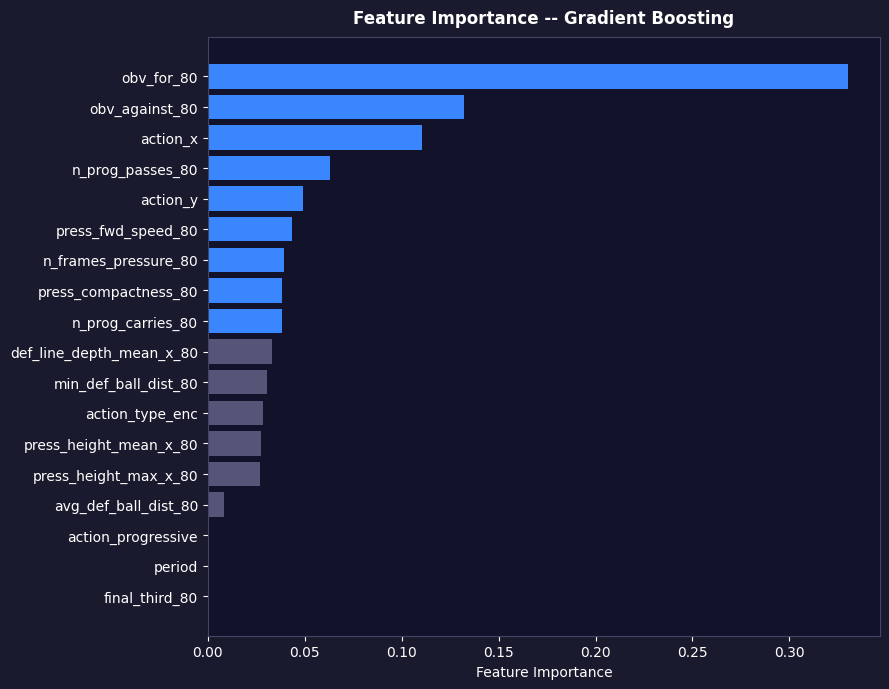

obv_for_80                  0.3303
obv_against_80              0.1323
action_x                    0.1106
n_prog_passes_80            0.0629
action_y                    0.0492
press_fwd_speed_80          0.0437
n_frames_pressure_80        0.0395
press_compactness_80        0.0383
n_prog_carries_80           0.0380
def_line_depth_mean_x_80    0.0331
min_def_ball_dist_80        0.0307
action_type_enc             0.0286
press_height_mean_x_80      0.0274
press_height_max_x_80       0.0268
avg_def_ball_dist_80        0.0082
action_progressive          0.0004
period                      0.0000
final_third_80              0.0000
dtype: float64


In [4]:
tree_model = models['Random Forest'] if results['Random Forest']['R2'] >= results['Gradient Boosting']['R2'] \
             else models['Gradient Boosting']
tree_name  = 'Random Forest' if results['Random Forest']['R2'] >= results['Gradient Boosting']['R2'] \
             else 'Gradient Boosting'

importances = pd.Series(tree_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7), facecolor='#1a1a2e')
ax.set_facecolor('#12122a')
ax.barh(importances.index, importances.values,
        color=['#3a86ff' if v >= importances.median() else '#555577' for v in importances.values])
ax.set_xlabel('Feature Importance', color='white')
ax.set_title(f'Feature Importance -- {tree_name}', color='white', fontweight='bold', pad=10)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('#444466')
plt.tight_layout()
plt.savefig('../model/feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(importances.sort_values(ascending=False).round(4))

## Action recommendation

Given a game state at the 80% mark, simulate different possible actions
and predict which leads to the highest OBV in the remaining 20%.

In [5]:
ACTION_TYPES = ['Pass', 'Carry', 'Shot', 'Duel', 'Clearance']

def recommend_action(state_dict, model, feature_cols, label_encoder, action_x=None, action_y=None):
    """
    Given a game state (all features except action-specific ones),
    predict OBV for each possible action type.
    Returns a Series sorted by predicted OBV descending.
    """
    preds = {}
    for act in ACTION_TYPES:
        row = state_dict.copy()
        row['action_type_enc']    = int(label_encoder.transform([act])[0]) \
                                    if act in label_encoder.classes_ else 0
        row['action_x']           = action_x if action_x is not None else state_dict.get('action_x', 60.0)
        row['action_y']           = action_y if action_y is not None else state_dict.get('action_y', 40.0)
        row['action_progressive'] = 1 if act in ('Pass', 'Carry') else 0
        vec = np.array([row[f] for f in feature_cols]).reshape(1, -1)
        preds[act] = float(model.predict(vec)[0])
    return pd.Series(preds).sort_values(ascending=False)

# Demo: take a test sample and show recommendations
sample_idx = 0
sample_row = dict(zip(FEATURE_COLS, X_test[sample_idx]))
actual_obv = y_test[sample_idx]
actual_act = le.inverse_transform([int(sample_row['action_type_enc'])])[0]

recs = recommend_action(sample_row, best_model, FEATURE_COLS, le)

print(f'Actual action taken  : {actual_act}')
print(f'Actual OBV outcome   : {actual_obv:.4f}')
print()
print('Predicted OBV by action:')
print(recs.round(4).to_string())
print(f'\nRecommended action   : {recs.idxmax()}')

Actual action taken  : Carry
Actual OBV outcome   : 0.0086

Predicted OBV by action:
Carry        0.0194
Clearance    0.0161
Duel         0.0156
Pass         0.0139
Shot         0.0088

Recommended action   : Carry


## Visualisation: recommendation + actual vs predicted

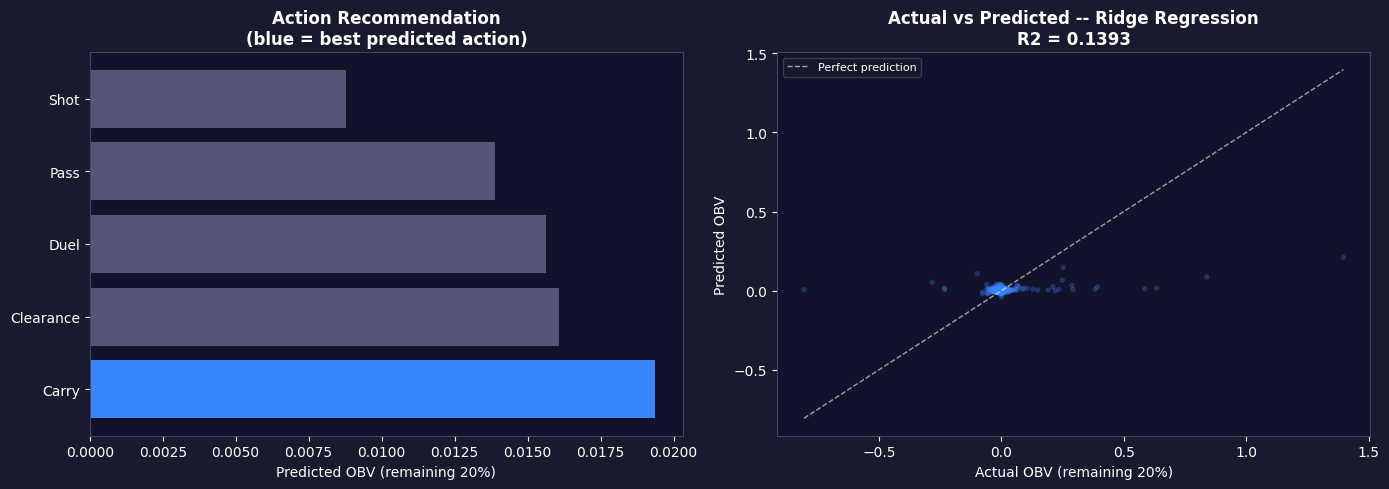

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#1a1a2e')

# Left: action recommendation
ax = axes[0]
ax.set_facecolor('#12122a')
colors = ['#3a86ff' if act == recs.idxmax() else '#555577' for act in recs.index]
ax.barh(recs.index, recs.values, color=colors)
ax.axvline(0, color='white', linewidth=0.8, alpha=0.5, linestyle='--')
ax.set_xlabel('Predicted OBV (remaining 20%)', color='white')
ax.set_title('Action Recommendation\n(blue = best predicted action)', color='white', fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('#444466')

# Right: actual vs predicted
ax2 = axes[1]
ax2.set_facecolor('#12122a')
y_pred_test = best_model.predict(X_test)
ax2.scatter(y_test, y_pred_test, alpha=0.3, s=15, color='#3a86ff', edgecolors='none')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax2.plot(lims, lims, 'w--', linewidth=1, alpha=0.6, label='Perfect prediction')
ax2.set_xlabel('Actual OBV (remaining 20%)', color='white')
ax2.set_ylabel('Predicted OBV', color='white')
ax2.set_title(f'Actual vs Predicted -- {best_name}\nR2 = {results[best_name]["R2"]:.4f}',
              color='white', fontweight='bold')
ax2.tick_params(colors='white')
ax2.legend(facecolor='#1a1a2e', labelcolor='white', edgecolor='#444466', fontsize=8)
for spine in ax2.spines.values():
    spine.set_color('#444466')

plt.tight_layout()
plt.savefig('../model/recommendation_and_fit.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## Save model

In [7]:
import pickle

with open('../model/best_model.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'label_encoder': le,
                 'feature_cols': FEATURE_COLS, 'model_name': best_name}, f)

print(f'Saved model : model/best_model.pkl  ({best_name})')
print()
print('Final metrics:')
for metric, val in results[best_name].items():
    print(f'  {metric:<10}: {val:.4f}')

Saved model : model/best_model.pkl  (Ridge Regression)

Final metrics:
  RMSE      : 0.0666
  MAE       : 0.0170
  R2        : 0.1393
  CV_R2     : 0.0491
